In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\SAMIR SINHA\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\SAMIR SINHA\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\SAMIR SINHA\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "C:\Users\SAMIR SINHA

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\SAMIR SINHA\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\SAMIR SINHA\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\SAMIR SINHA\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "C:\Users\SAMIR SINHA

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [2]:
df = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

In [3]:
# Now we need to perform a deep analysis on the numerical features present in our data

df.columns

Index(['id', 'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk'],
      dtype='object')

In [4]:
df = df.drop(columns = 'id', axis = 1)

In [5]:
df.columns

Index(['road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk'],
      dtype='object')

In [6]:
df.select_dtypes(include = 'number')

,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
0,2,0.06,35,1,0.13
1,4,0.99,35,0,0.35
2,4,0.63,70,2,0.30
3,4,0.07,35,1,0.21
4,1,0.58,60,1,0.56
...,...,...,...,...,...
517749,4,0.10,70,2,0.32
517750,4,0.47,35,1,0.26
517751,4,0.62,25,0,0.19
517752,3,0.63,25,3,0.51


In [7]:
numeric_cols = df.select_dtypes(include = 'number').columns.tolist()

In [8]:
numeric_cols

['num_lanes',
 'curvature',
 'speed_limit',
 'num_reported_accidents',
 'accident_risk']

In [9]:
df['num_lanes'].unique()

array([2, 4, 1, 3])

<Axes: >

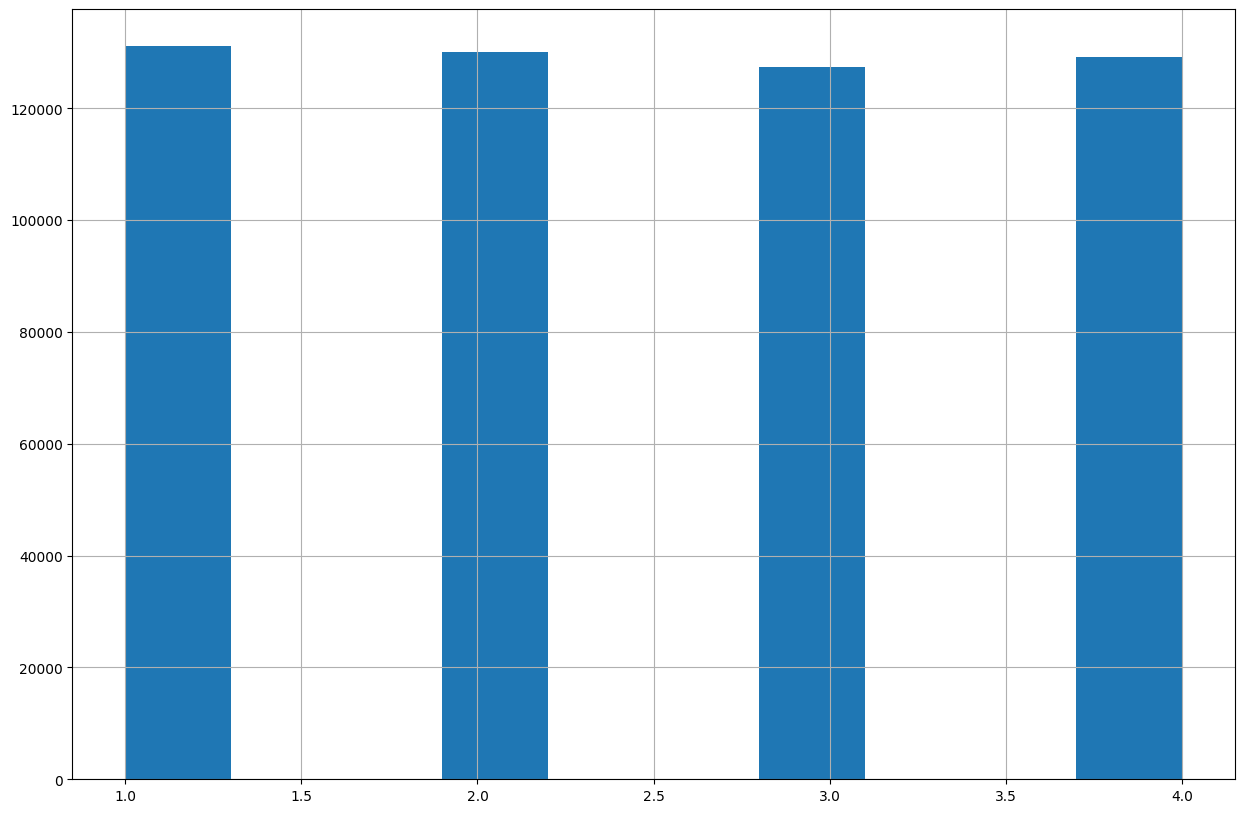

In [10]:
numeric1 = df['num_lanes']

numeric1

# whILE PERforming data preprocesing, always start off with checking what kind of distribution do they follow

# We can first check the scatter plot of this numeric column

df['num_lanes'].hist(figsize = (15,10))

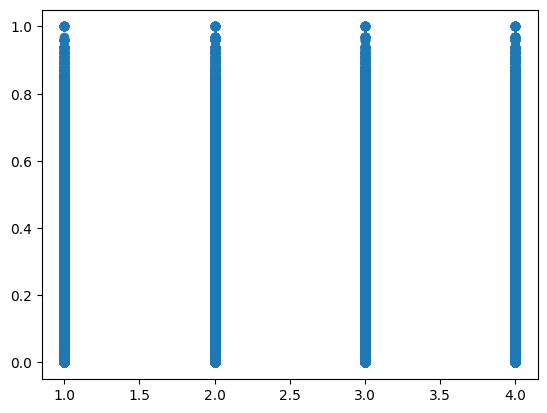

In [11]:
# Now we can check the scatter plots

plt.scatter(df['num_lanes'], df['accident_risk'])
plt.show()

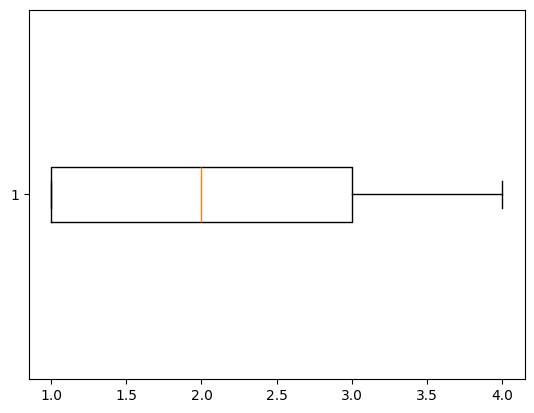

In [12]:
# Now since the above two plots could not give that much information, we can now try using the boxplot
plt.boxplot(df['num_lanes'], vert = False)
plt.show()

<Axes: >

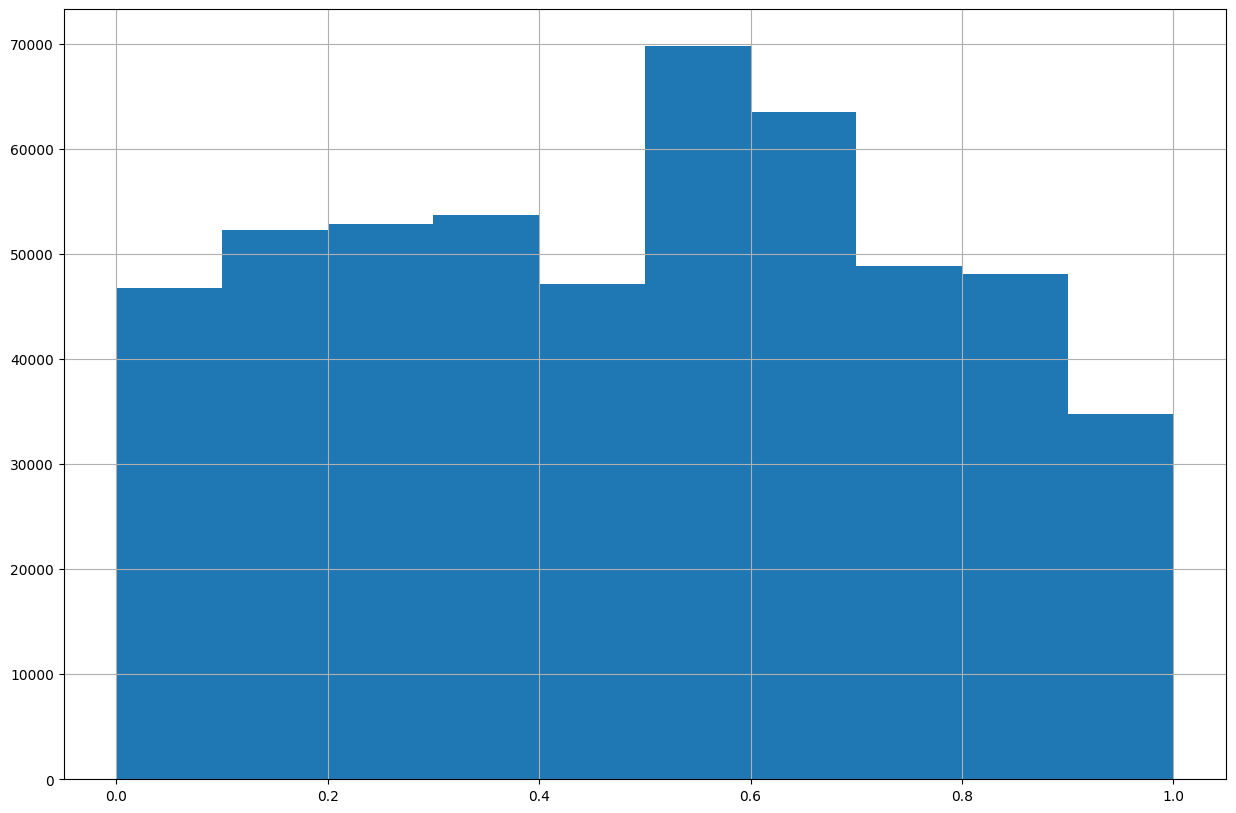

In [13]:
# As far as I could think, this column does not give that much information. We can move on to the next column.

# As we did with num_lanes, we will make a histplot for curvature

df['curvature'].hist(figsize = (15,10))

The above histplot tell us that at least this column doesn't need to be scaled as all the values are present between 0.0 and 1.0.

It also tells us that we mediocre number of straightish roads where the curvature is 0.0. Besides, we can also infer that we have very few roads that are highly curved. We have a lot of roads which have medium curvatures.

We can now bin these values into a new categorical features which is going to make the model much more powerful.



In [14]:
bins = [0.0, 0.4, 0.8, 1.0]

labels = ['low_curvature', 'medium_curvature', 'high_curvature']

curvature_category = pd.cut(df['curvature'], bins = bins, labels = labels, include_lowest = False)
df.insert(loc = 0, column = 'curvature_category', value = curvature_category)
df_test.insert(loc = 0, column = 'curvature_category', value = curvature_category)


In [15]:
df['curvature_category'].value_counts()

curvature_category
medium_curvature    227196
low_curvature       210940
high_curvature       78073
Name: count, dtype: int64

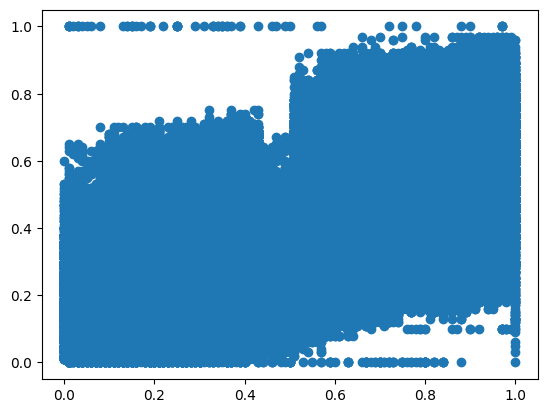

In [16]:
# Now we can move ahead the analysis that we are performing on curvature. We will now use scatterplot

plt.scatter(df['curvature'], df['accident_risk'])
plt.show()

This plot has so many curvatures between 0.2 and 0.6 and most of them have pretty low accident risk and it also makes sense for medium curvatures to have lesser number of accidents. So, one observation from this can be that since the lesser curvatures are kind of attached to lesser amount of accidents.



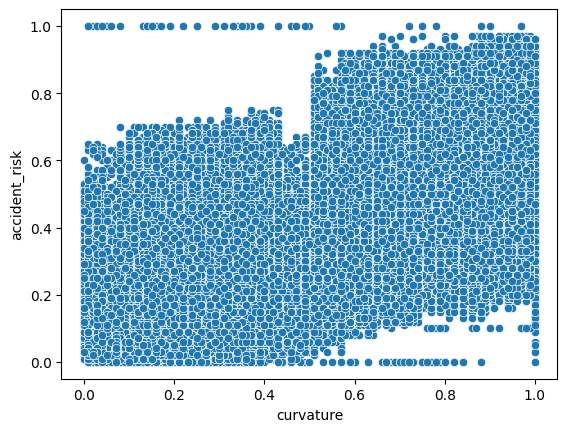

In [17]:
sns.scatterplot(x = df['curvature'], y = df['accident_risk'], data = df)
plt.show()

In [18]:
# We can investigate the few 1.0s that are present for low curvatures. They can either be flukes or they can give some good info

df_check = df.groupby('curvature_category')['accident_risk']

C:\Users\SAMIR SINHA\AppData\Local\Temp\ipykernel_15996\1237842482.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_check = df.groupby('curvature_category')['accident_risk']


In [19]:
low_curve_df = df[df['curvature_category'] == 'high_curvature'].copy()

risk = 0.5

risk2 = 0.7


high_risk = low_curve_df[(low_curve_df['accident_risk'] >= risk)]
#high_risk = low_curve_df[(low_curve_df['accident_risk'] >= risk ) & (low_curve_df['accident_risk'] <= risk2)]

print(len(high_risk))



high_risk_actual = (len(high_risk) / len(low_curve_df)) * 100

print(high_risk_actual)

31646
40.533859336774555


We will consider the threshold as 0.7. If the risk goes below 0.7, the accident risk is between 0.5 adn 0.7, the accident risk is medium but if the accident risk is between 0.7 and 1.0, the accident risk is high.

So, considering the threshold is set to medium, the low curvature gives percentages of accidents as 2.72 which is pretty low and when it is more than 0.7, it drops down to 0.02 something

When we consider the threshold to be greater than 0.7 for medium curvature, the accident risk rises to 26% which clearly shows medium curvatures are dangerous. 

Now taking the high curvatures into consideration, the threshold reveals the accident risk percentage to be 40%. 

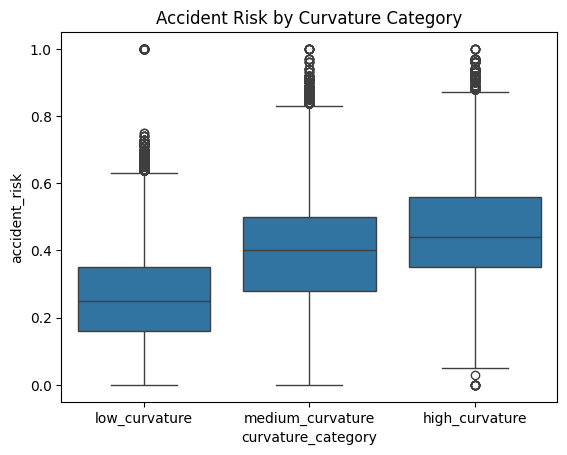

In [20]:
# We can now check the correlation of this curvature category with the accident risk column

sns.boxplot(x = 'curvature_category', y = 'accident_risk', orient = 'vertical', data = df)
plt.title('Accident Risk by Curvature Category')
plt.show()

We can infer quite a few things from this boxplot. The median value of low curvature is at around 0.25, for medium curvature, it's around 0.4 and for high curvature, that's around 0.45. We can now safely say that having a low curvature road is way better than having a medium curvature or a high curvature road. The jump from low_curvature to medium curvature is higher than from medium_cur to high_cur. So, this assures our claims.

The second thing to note here is that there are low value outliers in the case of high_curvature and this proves that just having high_curvature doesn't mean that accident risks increase but it goes on to show that other probable factors like speed limit and all matter as much.

In [21]:
# Now as the final step, we can use .value_counts to know what kind of distribution does this column follow?

# Value counts is the most basic method to look for the distribution of data.

df['curvature_category'].value_counts()



curvature_category
medium_curvature    227196
low_curvature       210940
high_curvature       78073
Name: count, dtype: int64

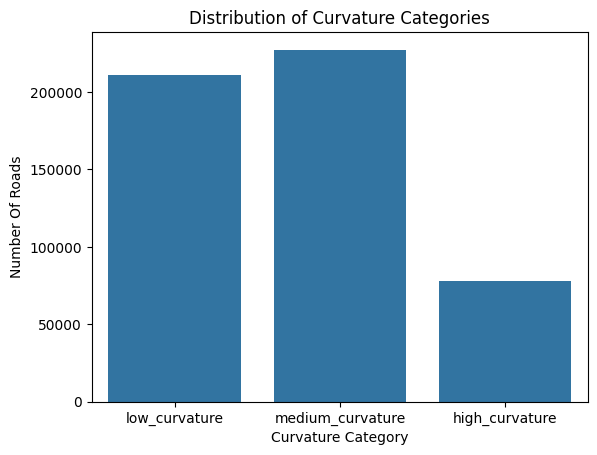

In [22]:
# As the second technique, we can use bar charts to visualize it

# For categorical variables, we can only use PMF and PDF. This bar chart gives us the PMF.

sns.countplot(x = 'curvature_category', data = df)
plt.title('Distribution of Curvature Categories')
plt.xlabel('Curvature Category')
plt.ylabel('Number Of Roads')
plt.show()

From the above Probability Mass Function, we can easily infer that high_curvature is a little imbalanced here and so we might need to perform Oversampling, SMOTE, etc techniques to compensate for that or my other inference is that maybe we can rely on DTs adn RFRs since they are decent with handling imbalanced classes.

<Axes: xlabel='curvature', ylabel='Density'>

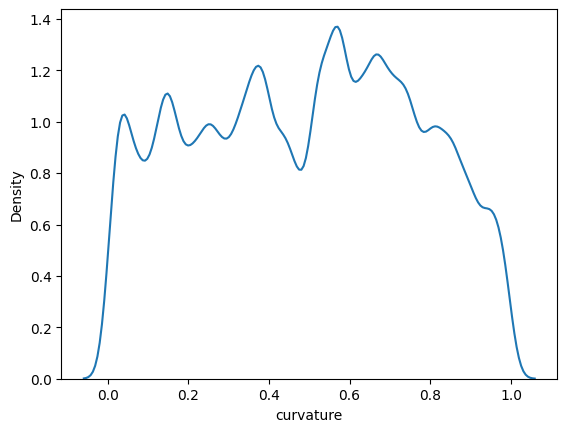

In [23]:
sns.kdeplot(df['curvature'])

<Axes: ylabel='Density'>

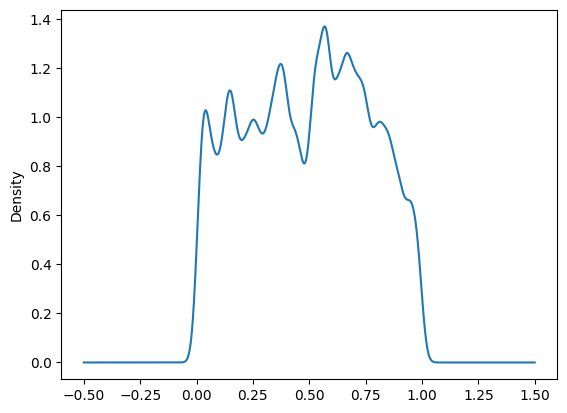

In [24]:
df['curvature'].plot(kind = 'density')

In [25]:
df['curvature'].max()

1.0

In [26]:
# Even though this distribution is multi modal, we muight not want to change the distribution that it follows.

# To compensate for this, we can end up using our tree based models like XGBoost, Light GBM, etc

# So, with this information, we can now move on to the next column


df['speed_limit']

0         35
1         35
2         70
3         35
4         60
          ..
517749    70
517750    35
517751    25
517752    25
517753    45
Name: speed_limit, Length: 517754, dtype: int64

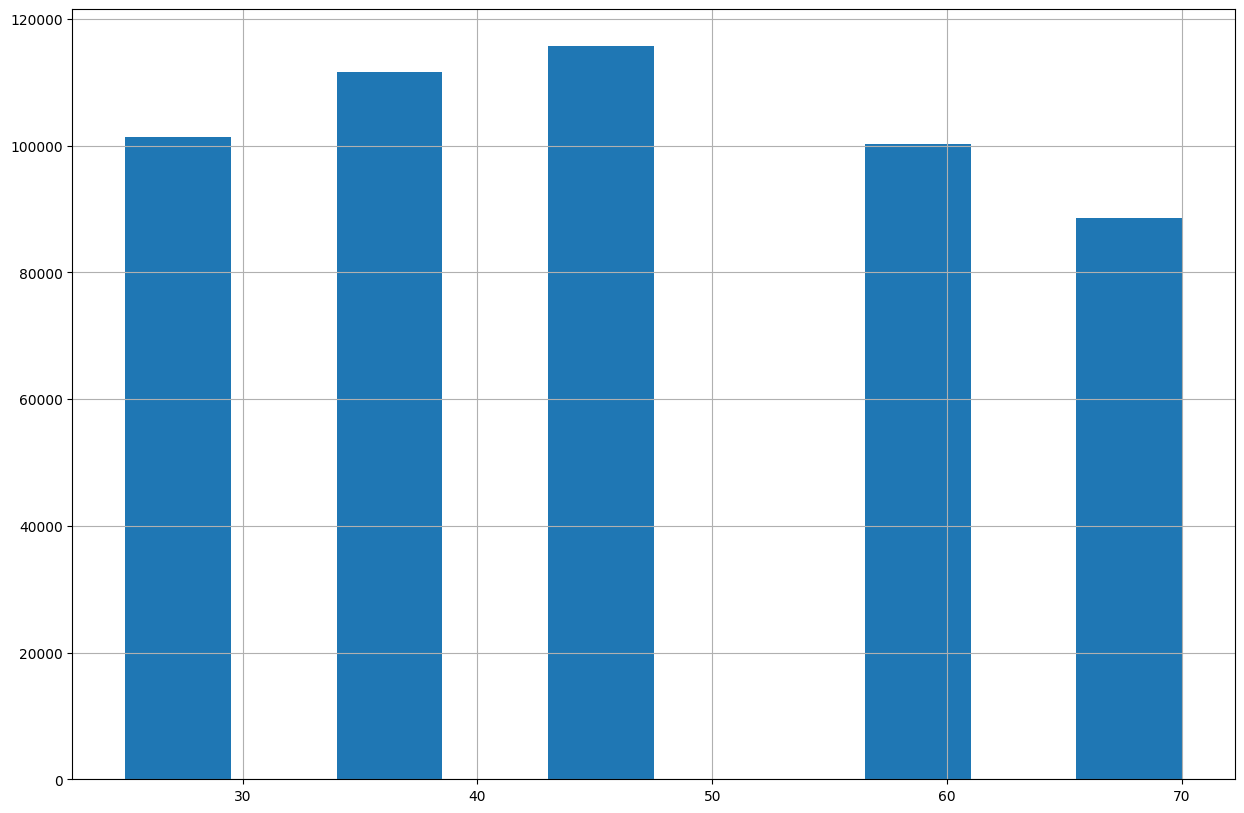

In [27]:

df['speed_limit'].hist(figsize = (15, 10))
plt.show()

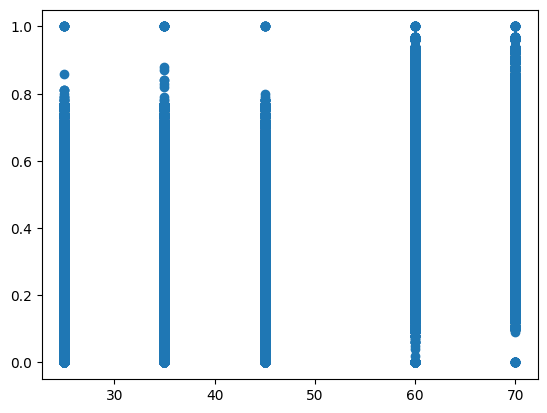

In [28]:
plt.scatter(df['speed_limit'], df['accident_risk'])
plt.show()

We can analyse here that the values in speed limit are very discrete. What's weird is that there is an accident at low speed and other medium speeds. Accidents at higher speed are anyways predictable but we need to perform some check related to that.

C:\Users\SAMIR SINHA\anaconda3\Lib\site-packages\seaborn\_base.py:1601: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


<Axes: ylabel='speed_limit'>

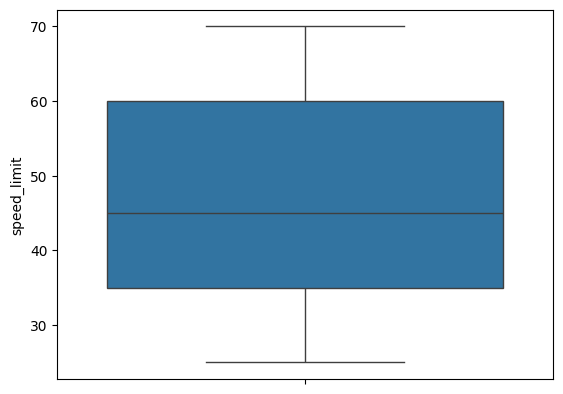

In [29]:
# We can now perform boxplot analysis
sns.boxplot(y = df['speed_limit'],orient = 'hori')

C:\Users\SAMIR SINHA\AppData\Local\Temp\ipykernel_15996\3716308106.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['speed_limit'])


<Axes: xlabel='speed_limit', ylabel='Density'>

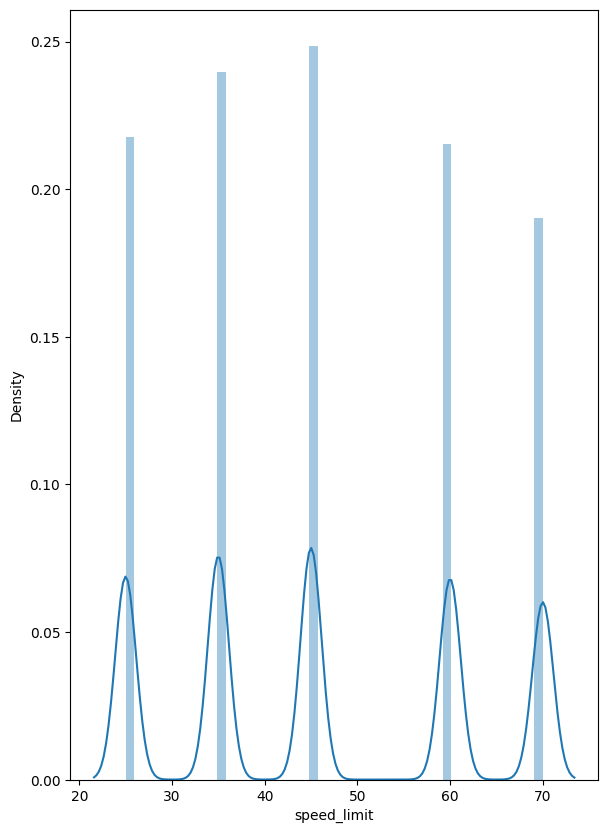

In [30]:
plt.figure(figsize = (15,10))
plt.subplot(1,2,1)
sns.distplot(df['speed_limit'])

In [31]:
df['speed_limit'].unique()

array([35, 70, 60, 45, 25])

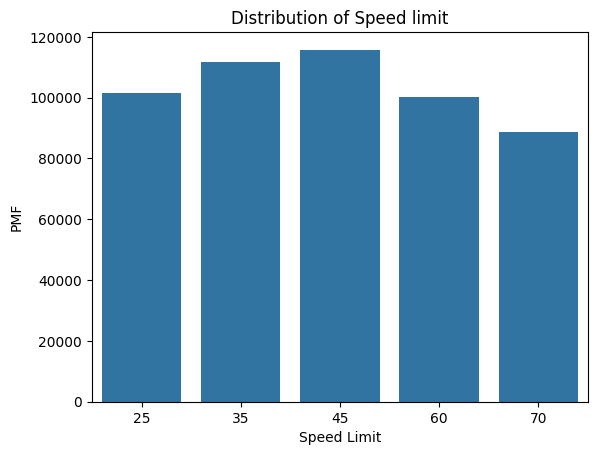

In [32]:

sns.countplot(x = 'speed_limit', data = df)
plt.title('Distribution of Speed limit')
plt.xlabel('Speed Limit')
plt.ylabel('PMF')
plt.show()

So, speed limit is not a continuous value since it has only 5 discrete values inside it. So, it follows a Discrete Multimodal Distribution and not other common distribution like Gaussian Distribution or Normal Distribution.

{'whiskers': [<matplotlib.lines.Line2D at 0x2566fdf4770>,
 'caps': [<matplotlib.lines.Line2D at 0x2566fdf4cb0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2566fdf44a0>],
 'medians': [<matplotlib.lines.Line2D at 0x2566fdf5220>],
 'fliers': [<matplotlib.lines.Line2D at 0x2566fdf5550>],
 'means': []}

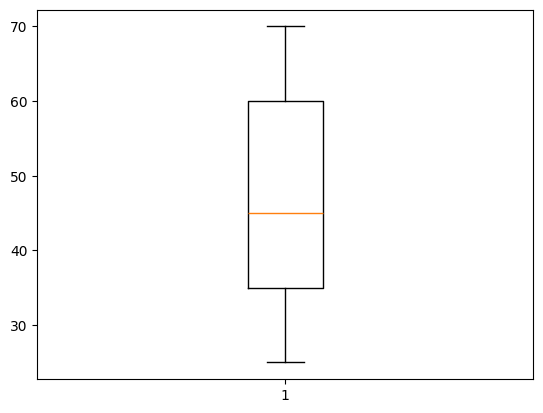

In [33]:
plt.boxplot(df['speed_limit'])

In [34]:
outlier_check = ((df['speed_limit'] < 70) & (df['accident_risk'] == 0.0))

outlier_row = df[outlier_check]

print(outlier_row)



       curvature_category road_type  num_lanes  curvature  speed_limit  \
31          low_curvature     rural          1       0.01           60   
46          low_curvature     urban          1       0.01           35   
932         low_curvature     urban          2       0.10           35   
1122     medium_curvature     rural          3       0.55           35   
1181       high_curvature     rural          4       0.82           25   
...                   ...       ...        ...        ...          ...   
515667      low_curvature     urban          2       0.07           35   
516430      low_curvature     urban          1       0.26           25   
516526      low_curvature     urban          4       0.23           35   
516763      low_curvature     urban          1       0.07           25   
517394      low_curvature   highway          3       0.10           35   

        lighting weather  road_signs_present  public_road time_of_day  \
31           dim   clear              

In [35]:
# Since we are going to use DTs or something similar, we don't need to peform feature scaling as these algoritms are proficient in handling the ambiguity.
df['num_reported_accidents']

0         1
1         0
2         2
3         1
4         1
         ..
517749    2
517750    1
517751    0
517752    3
517753    2
Name: num_reported_accidents, Length: 517754, dtype: int64

In [36]:
df['num_reported_accidents'].nunique(), df['num_reported_accidents'].unique()

(8, array([1, 0, 2, 3, 4, 5, 6, 7]))

<Axes: >

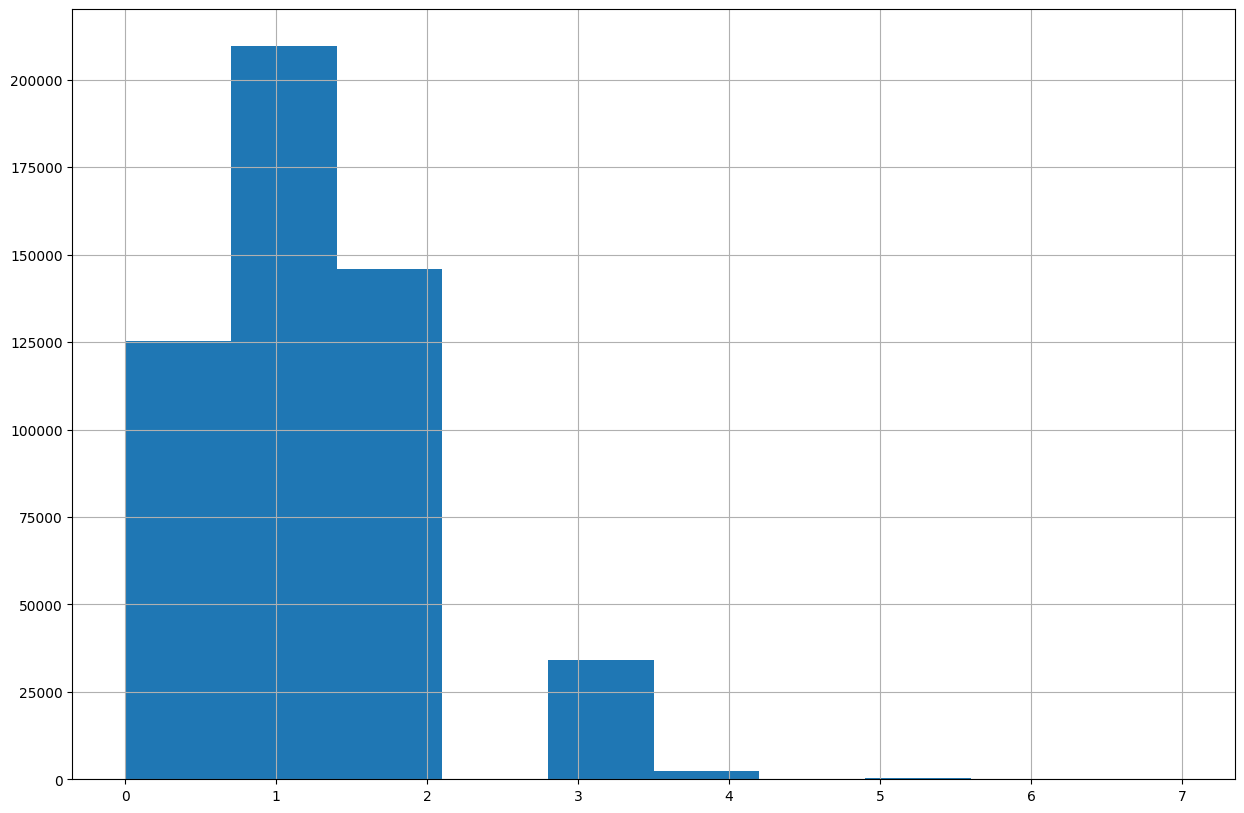

In [37]:
# First go with a hist plot to analyze the 
df['num_reported_accidents'].hist(figsize = (15,10))

In [38]:
df['num_reported_accidents'].describe()

count    517754.000000
mean          1.187970
std           0.895961
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           7.000000
Name: num_reported_accidents, dtype: float64

In [39]:
df['accident_risk']

0         0.13
1         0.35
2         0.30
3         0.21
4         0.56
          ... 
517749    0.32
517750    0.26
517751    0.19
517752    0.51
517753    0.22
Name: accident_risk, Length: 517754, dtype: float64

In [40]:
df['accident_risk'].mean() 

np.float64(0.3523774031683)

<Axes: xlabel='num_reported_accidents'>

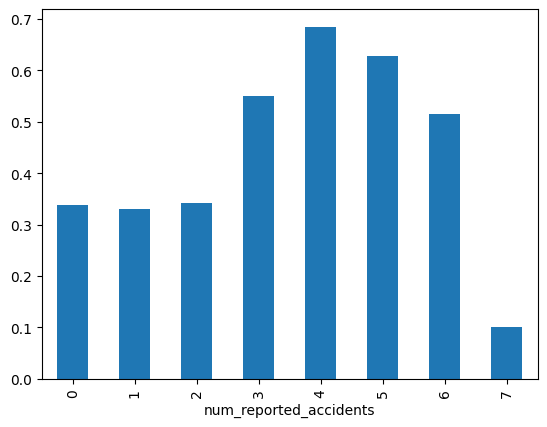

In [41]:
df.groupby('num_reported_accidents')['accident_risk'].mean().plot(kind = 'bar')

In [42]:
df['num_reported_accidents'].isnull().value_counts(), df.shape

(num_reported_accidents
 False    517754
 Name: count, dtype: int64,
 (517754, 14))

In [43]:
df[df['num_reported_accidents'] == 7]

,curvature_category,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
60437,low_curvature,urban,2,0.27,35,night,clear,False,True,evening,True,False,7,0.1
102140,NaN,urban,3,0.00,70,daylight,foggy,False,True,afternoon,True,True,7,0.1


In [44]:
df = df[df['num_reported_accidents'] <= 6]

C:\Users\SAMIR SINHA\AppData\Local\Temp\ipykernel_15996\3119907620.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['accident_log'] = np.log1p(df['num_reported_accidents'])
C:\Users\SAMIR SINHA\AppData\Local\Temp\ipykernel_15996\3119907620.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['accident_sqrt'] = np.sqrt(df['num_reported_accidents'])


<Axes: xlabel='accident_log'>

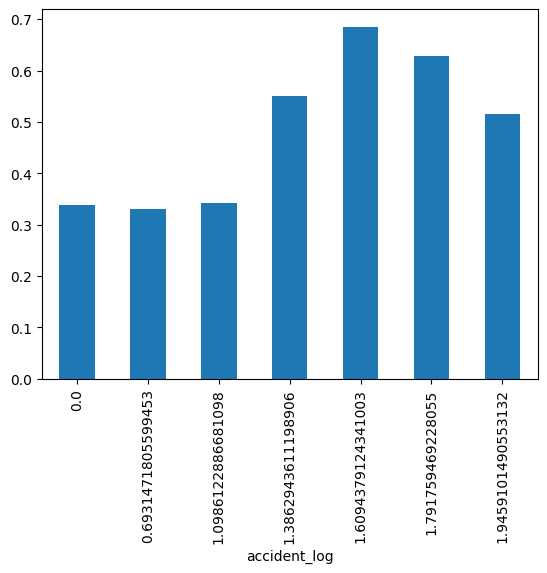

In [45]:
df['accident_log'] = np.log1p(df['num_reported_accidents'])
df['accident_sqrt'] = np.sqrt(df['num_reported_accidents'])

df.groupby('accident_log')['accident_risk'].mean().plot(kind = 'bar')

<Axes: xlabel='accident_sqrt'>

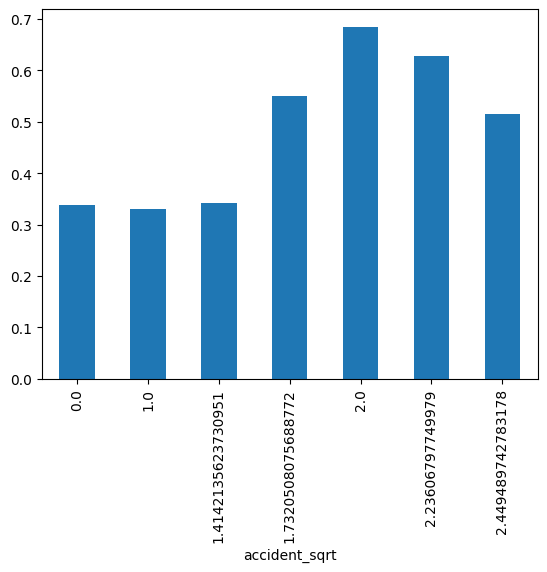

In [46]:
df.groupby('accident_sqrt')['accident_risk'].mean().plot(kind = 'bar')

In [47]:
df = df.drop(columns = ['accident_log', 'accident_sqrt'], axis = 1)

In [48]:
df

,curvature_category,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,low_curvature,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,high_curvature,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,medium_curvature,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,low_curvature,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,medium_curvature,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,low_curvature,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,medium_curvature,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,medium_curvature,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,medium_curvature,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51


In [49]:
# After this analysis, we are done with pre processing the numerical columns, we can now head to the categorical columns

df.dtypes

curvature_category        category
road_type                   object
num_lanes                    int64
curvature                  float64
speed_limit                  int64
lighting                    object
weather                     object
road_signs_present            bool
public_road                   bool
time_of_day                 object
holiday                       bool
school_season                 bool
num_reported_accidents       int64
accident_risk              float64
dtype: object

In [50]:
# Now we can jsut take all the categorical columns and perform and perform Encoding on all of them

df.head(5)

,curvature_category,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,low_curvature,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,high_curvature,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,medium_curvature,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,low_curvature,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,medium_curvature,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [51]:
df['curvature_category'].fillna(df['curvature_category'].mode()[0], inplace = True)
train_mode = df['curvature_category'].mode()[0]

df_test['curvature_category'].fillna(train_mode, inplace = True)


C:\Users\SAMIR SINHA\AppData\Local\Temp\ipykernel_15996\1721497034.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['curvature_category'].fillna(df['curvature_category'].mode()[0], inplace = True)
C:\Users\SAMIR SINHA\AppData\Local\Temp\ipykernel_15996\1721497034.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are se

In [52]:
from sklearn.model_selection import train_test_split
X = df.iloc[:, :-1]

y = df.iloc[:, -1]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [53]:
df_test = df_test.drop(columns = ['id'], axis =1)

In [54]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
# We can simply first define the columns that we need for Ordinal or One Hot Encoding
nominal_encoding = ['road_type', 'weather', 'road_signs_present', 'public_road', 'school_season','holiday']
ordinal_columns = ['lighting', 'time_of_day','curvature_category',]

ordinal_encoding_lighting = ['daylight', 'dim', 'night']
ordinal_encoding_time = ['morning', 'afternoon', 'evening']
ordinal_encoding_curvature_category = ['low_curvature', 'medium_curvature', 'high_curvature']

# We will apply Standard Scaler for scaling all the numerical columns

numerical = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']

preprocessor = ColumnTransformer(
    transformers = [
        ('onehotencoder', OneHotEncoder(drop = 'first', sparse_output = False), nominal_encoding),
        ('ordinal', OrdinalEncoder(categories = [ordinal_encoding_lighting, ordinal_encoding_time,ordinal_encoding_curvature_category]), ordinal_columns),
         ('stdscaler', StandardScaler(), numerical)      
         ],
    remainder = 'passthrough'
)

X_train_transform = preprocessor.fit_transform(X_train)
X_validate_transform = preprocessor.transform(X_test)
X_test_transform = preprocessor.transform(df_test)

In [55]:
feature_names = preprocessor.get_feature_names_out()
feature_names1 = preprocessor.get_feature_names_out()
feature_names2 = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_transform, columns = feature_names, index = X_train.index)

X_validate_df = pd.DataFrame(X_validate_transform, columns = feature_names1, index = X_test.index)

X_test_df = pd.DataFrame(X_test_transform, columns = feature_names2, index = df_test.index)

In [56]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state = 42)

y_pred = tree.fit(X_train_df, y_train)

In [57]:
from sklearn.metrics import mean_squared_error
y_test1 = tree.predict(X_validate_df)
print(mean_squared_error(y_test1, y_test))

0.00684449661948648


In [58]:
submission = pd.read_csv("sample_submission.csv")

In [59]:
submission.head(2)

submission.shape

(172585, 2)

In [60]:
y_test = tree.predict(X_test_transform)

C:\Users\SAMIR SINHA\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [61]:
y_test.shape

(172585,)

In [63]:
submission['accident_risk'] = y_test

In [65]:
submission.to_csv("submission1_Decision_Tree.csv", index = False)